In [1]:
from pandas import concat, read_csv

REGIONS = ('DE', 'DR', 'V')
CSV_COLUMNS = ('I', 'R', 'E', 'A', 'DE', 'DA', 'H', 'M')
NUMERIC_COLUMNS = ('DA', 'H', 'M')
converters = {
    col: lambda value: value.replace(',', '')
    for col in NUMERIC_COLUMNS
}
df = concat(
    (
        read_csv(
            f'R/{region}.csv',
            index_col='I',
            usecols=CSV_COLUMNS,
            converters=converters,
            na_filter=False
        )
        for region in REGIONS
    ),
    keys=REGIONS,
    names=('RE',)
)
df

R   E  A  DE    DA      H      M
RE I                                    
DE 1    T   0  0   8  2947   1425   4611
   1    D   1  0   3  1818      0    650
   1    D   2  0   7  4735    487    308
   1    S   1  0   3  2078   2748      0
   1    S   1  1   3   269   5848    189
...    ..  .. ..  ..   ...    ...    ...
V  491  T  12  1   9  7745     12  12986
   491  D   6  0  10  7838   1433      0
   491  D  12  2   8  8688      0    472
   491  S   2  8   7  1041  11310    256
   491  S   2  7   8  3005   8648    548

[9500 rows x 7 columns]

In [2]:
from string import digits

digit_dict = {'': 0, 'T': 1, 'D': 2, 'S': 3}
for i, d in enumerate(digits, 1):
    digit_dict[d] = i
digit_dict

{'': 0,
 'T': 1,
 'D': 2,
 'S': 3,
 '0': 1,
 '1': 2,
 '2': 3,
 '3': 4,
 '4': 5,
 '5': 6,
 '6': 7,
 '7': 8,
 '8': 9,
 '9': 10}

In [3]:
from pandas import DataFrame
from numpy import uint8

result = {}
for col_name, max_len in df.map(len).max().items():
    for i in range(-max_len, 0):
        result[f'{col_name}{-i}'] = df[col_name].str[i].map(digit_dict).fillna(0).astype(uint8)
result_df = DataFrame(result)
result_df

R1  E2  E1  A2  A1  DE2  DE1  DA5  DA4  DA3  ...  H5  H4  H3  H2  H1  \
RE I                                                 ...                       
DE 1     1   0   1   0   1    0    9    0    3   10  ...   0   2   5   3   6   
   1     2   0   2   0   1    0    4    0    2    9  ...   0   0   0   0   1   
   1     2   0   3   0   1    0    8    0    5    8  ...   0   0   5   9   8   
   1     3   0   2   0   1    0    4    0    3    1  ...   0   3   8   5   9   
   1     3   0   2   0   2    0    4    0    0    3  ...   0   6   9   5   9   
...     ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ...  ..  ..  ..  ..  ..   
V  491   1   2   3   0   2    0   10    0    8    8  ...   0   0   0   2   3   
   491   2   0   7   0   1    2    1    0    8    9  ...   0   2   5   4   4   
   491   2   2   3   0   3    0    9    0    9    7  ...   0   0   0   0   1   
   491   3   0   3   0   9    0    8    0    2    1  ...   2   2   4   2   1   
   491   3   0   3   0   8    0    9    0    4    1  ...   0   9   7   5   9   

        M5  M4  M3  M2  M1  
RE I                        
DE 1     0   5   7   2   2  
   1     0   0   7   6   1  
   1     0   0   4   1   9  
   1     0   0   0   0   1  
   1     0   0   2   9  10  
...     ..  ..  ..  ..  ..  
V  491   2   3  10   9   7  
   491   0   0   0   0   1  
   491   0   0   5   8   3  
   491   0   0   3   6   7  
   491   0   0   6   5   9  

[9500 rows x 22 columns]

In [4]:
df_numpy = result_df.to_numpy().reshape(-1, 10, 22)
df_0, df_1 = df_numpy[:, :, 0], df_numpy[:, :, 1:]
df_0.shape, df_1.shape

((950, 10), (950, 10, 21))

In [6]:
from pathlib import Path
from tensorflow.random import shuffle
import tensorflow as tf
from tensorflow import gather

image_paths = sorted(map(str, Path().rglob('*.png')))
data_count = len(image_paths)
indices = shuffle(tf.range(data_count))
X_shuffled = gather(image_paths, indices)
y_shuffled_0 = gather(df_0, indices)
y_shuffled_1 = gather(df_1, indices)

train_size = int(data_count * .9)
train_X, val_X = X_shuffled[:train_size], X_shuffled[train_size:]
train_y_0, val_y_0 = y_shuffled_0[:train_size], y_shuffled_0[train_size:]
train_y_1, val_y_1 = y_shuffled_1[:train_size], y_shuffled_1[train_size:]
train_X.shape, train_y_0.shape, train_y_1.shape

I0000 00:00:1774221758.315323     213 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5555 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:06:00.0, compute capability: 8.6


(TensorShape([855]), TensorShape([855, 10]), TensorShape([855, 10, 21]))

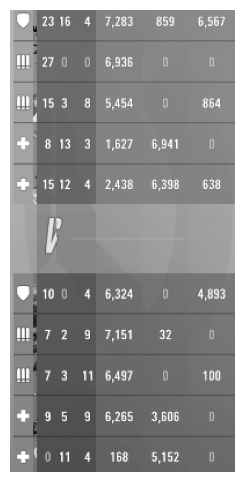

tf.Tensor(
[[ 3  4  2  7  0  5  0  8  3  9  4  0  0  9  6 10  0  7  6  7  8]
 [ 3  8  0  1  0  1  0  7 10  4  7  0  0  0  0  1  0  0  0  0  1]
 [ 2  6  0  4  0  9  0  6  5  6  5  0  0  0  0  1  0  0  9  7  5]
 [ 0  9  2  4  0  4  0  2  7  3  8  0  7 10  5  2  0  0  0  0  1]
 [ 2  6  2  3  0  5  0  3  5  4  9  0  7  4 10  9  0  0  7  4  9]
 [ 2  1  0  1  0  5  0  7  4  3  5  0  0  0  0  1  0  5  9 10  4]
 [ 0  8  0  3  0 10  0  8  3  6  2  0  0  0  4  3  0  0  0  0  1]
 [ 0  8  0  4  2  2  0  7  5 10  8  0  0  0  0  1  0  0  2  1  1]
 [ 0 10  0  6  0 10  0  7  3  7  6  0  4  7  1  7  0  0  0  0  1]
 [ 0  1  2  2  0  5  0  0  2  7  9  0  6  2  6  3  0  0  0  0  1]], shape=(10, 21), dtype=uint8)


In [7]:
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.image import decode_png, resize
from tensorflow.io import read_file
from matplotlib.pyplot import figure, axis, imshow, show
from numpy import array


def preprocess_image(path, label):
    image = decode_png(read_file(path), channels=1)[230:930, 530:1370]
    hud_parts = [
        image[:, :40], image[:, 390:420], image[:, 450:480],
        image[:, 500:530], image[:, 570:640], image[:, 670:740], image[:, 770:]
    ]
    cropped = tf.concat(hud_parts, axis=1)
    resized = resize(cropped, (400, 194)) / 255
    return resized, label


def make_dataset(X, y, shuffle=False, batch_size=32):
    ds = Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(data_count)
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_X, train_y_1, True)
val_ds = make_dataset(val_X, val_y_1, True)
for x_batch, y_batch in train_ds.take(1):
    figure(figsize=(6, 6))
    axis('off')
    imshow(x_batch[0], cmap='gray')
    show()
    print(y_batch[0])

build_model에서 모델을 구축할 건데 Input은 흑백 이미지고 shape은 (400, 194, 1)이야. Output 1의 shape은 (10, 4)고 Output 2의 shape은 (10, 21, 11)이야. 한 이미지 내의 여러 기호와 여러 자리의 숫자를 인식하는 모델인데 각 기호 및 숫자는 최대 10 * 22(세로 * 가로) Grid 형태로 구성돼 있어. Output 1은 기호, Output 2은 숫자를 인식해야 해. 각 기호 및 숫자는 절대적인 위치는 변하지만 상대적인 순서 및 위치는 변하지 않아. 이 가로, 세로 순서를 이용하여 출력을 내는 게 중요해. 1열은 기호, 2열 ~ 22열은 숫자인 셈이지. 참고로 각 숫자는 약 9 * 16 픽셀의 크기고 인쇄 폰트 형태야. 각 기호와 숫자는 비어 있을 수도 있기 때문에 Blank를 포함해서 4 클래스와 11 클래스야. 이때 어떤 모델 구조가 가장 적합할까?

In [11]:
import tensorflow as tf
from tensorflow.keras.backend import clear_session
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    LayerNormalization,
    Dropout,
    Flatten,
    Reshape,
    MultiHeadAttention,
    Add,
    Layer,
    Lambda
)
from tensorflow.keras.losses import SparseCategoricalCrossentropy


# --------------------------
# Transformer block
# --------------------------
class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


# --------------------------
# Build OCR model
# --------------------------
def build_model():
    inputs = Input(shape=(400, 194, 1))

    # Backbone CNN
    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 400->200, 194->97

    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 200->100, 97->48

    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 100->50, 48->24

    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D(pool_size=(5, 1))(x)  # 50->10, 24->24

    # Reduce width to 22
    x = Lambda(lambda t: tf.image.resize(t, (10, 22)))(x)

    # x shape ≈ (10, 22, 256)
    
    # Flatten to sequence for Transformer
    seq_len = 10 * 22
    x_seq = Reshape((seq_len, 256))(x)

    # Add positional encoding (simple learned)
    pos_emb = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=256)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_encoding = pos_emb(positions)
    pos_encoding = tf.expand_dims(pos_encoding, axis=0)  # (1, seq_len, dim)
    
    x_seq = x_seq + pos_encoding

    # Transformer blocks
    for _ in range(4):
        x_seq = TransformerBlock(embed_dim=256, num_heads=4, ff_dim=512)(x_seq)

    # Back to grid
    x_grid = Reshape((10, 22, 256))(x_seq)

    # Symbol head (column 0)
    symbol_feat = x_grid[:, :, 0, :]  # shape: (batch, 10, 256)
    # symbol_out = Dense(4, name='output_1')(symbol_feat)

    # Digit head (columns 1~21)
    digit_feat = x_grid[:, :, 1:, :]  # shape: (batch, 10, 21, 256)
    digit_out = Dense(11, name='output_2')(digit_feat)

    return Model(inputs=inputs, outputs=digit_out)

clear_session()
model = build_model()
model.compile(
    'adamw',
    # SparseCategoricalCrossentropy(from_logits=True, ignore_class=0),
    SparseCategoricalCrossentropy(from_logits=True),
    metrics=['sparse_categorical_accuracy']
)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400, 194, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 400, 194, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 97, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 97, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 48, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 48, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 10, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 220, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 220, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 10, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 10, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_2 (Dense)                │ (None, 10, 21, 11)     │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499,083 (9.53 MB)

 Trainable params: 2,499,083 (9.53 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    train_ds,
    epochs=128,
    callbacks=EarlyStopping(patience=16, verbose=1, restore_best_weights=True),
    validation_data=val_ds
)

Epoch 1/128


I0000 00:00:1774221910.124598     277 service.cc:153] XLA service 0x72eb5c060020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774221910.124655     277 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070 Ti, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1774221910.530843     277 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1774221911.108442     277 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774221911.723078     277 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1774221912.042500     277 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19086__.183
I0000 00:00:1774221915.590165     411 subprocess_compilation.cc:348] ptxas warning : Regis

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 3.3623 - sparse_categorical_accuracy: 0.2474

W0000 00:00:1774221946.387807     279 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774221947.124224     279 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19086__.183
I0000 00:00:1774221948.993644     939 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_96', 144 bytes spill stores, 128 bytes spill loads

I0000 00:00:1774221954.321032     941 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_36', 9712 bytes spill stores, 9628 bytes spill loads

I0000 00:00:1774221954.615131     942 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_72', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1774221954.904142     944 subprocess_compilation.cc:348]

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 3.3376 - sparse_categorical_accuracy: 0.2491   

W0000 00:00:1774221976.835133     276 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774221976.861476     276 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20338__.44
W0000 00:00:1774221979.644150     276 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774221979.661045     276 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20338__.44
I0000 00:00:1774221979.991667    1545 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_34', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1774221981.720460    1552 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37', 32 bytes 

27/27 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - loss: 2.6968 - sparse_categorical_accuracy: 0.2938 - val_loss: 2.1712 - val_sparse_categorical_accuracy: 0.3402
Epoch 2/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 2.1815 - sparse_categorical_accuracy: 0.3349 - val_loss: 2.1352 - val_sparse_categorical_accuracy: 0.3402
Epoch 3/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - loss: 2.1685 - sparse_categorical_accuracy: 0.3363 - val_loss: 2.1296 - val_sparse_categorical_accuracy: 0.3402
Epoch 4/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - loss: 2.1586 - sparse_categorical_accuracy: 0.3373 - val_loss: 2.1150 - val_sparse_categorical_accuracy: 0.3402
Epoch 5/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - loss: 2.1676 - sparse_categorical_accuracy: 0.3325 - val_loss: 2.1446 - val_sparse_categorical_accuracy: 0.3402
Epoch 6/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 2.1203 - sparse_categorical_accuracy: 0.3369 - val_loss: 1.9485 - val_sparse_categorical_accuracy: 0.3640
Epoch 7/128


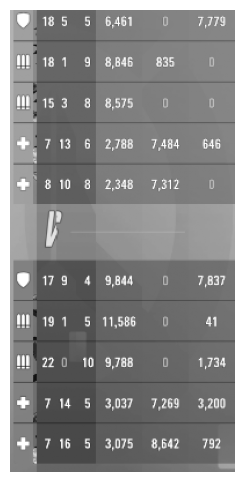

tf.Tensor(
[[ 2  9  0  6  0  6  0  7  5  7  2  0  0  0  0  1  0  8  8  8 10]
 [ 2  9  0  2  0 10  0  9  9  5  7  0  0  9  4  6  0  0  0  0  1]
 [ 2  6  0  4  0  9  0  9  6  8  6  0  0  0  0  1  0  0  0  0  1]
 [ 0  8  2  4  0  7  0  3  8  9  9  0  8  5  9  5  0  0  7  5  7]
 [ 0  9  2  1  0  9  0  3  4  5  9  0  8  4  2  3  0  0  0  0  1]
 [ 2  8  0 10  0  5  0 10  9  5  5  0  0  0  0  1  0  8  9  4  8]
 [ 2 10  0  2  0  6  2  2  6  9  7  0  0  0  0  1  0  0  0  5  2]
 [ 3  3  0  1  2  1  0 10  8  9  9  0  0  0  0  1  0  2  8  4  5]
 [ 0  8  2  5  0  6  0  4  1  4  8  0  8  3  7 10  0  4  3  1  1]
 [ 0  8  2  7  0  6  0  4  1  8  6  0  9  7  5  3  0  0  8 10  3]], shape=(10, 21), dtype=uint8)


In [14]:
for x_batch, y_batch in val_ds.take(1):
    figure(figsize=(6, 6))
    axis('off')
    imshow(x_batch[0], cmap='gray')
    show()
    print(y_batch[0])

In [68]:
import numpy as np
import tensorflow as tf

X_true = []
y_true = []
for X, y in val_ds:
    X_true.append(X.numpy())
    y_true.append(y.numpy())
X_true = np.concatenate(X_true, axis=0)
y_true = np.concatenate(y_true, axis=0)
X_true.shape, y_true.shape

((95, 400, 194, 1), (95, 10, 21))

In [69]:
logits = model.predict(X_true)
probs = tf.nn.softmax(logits, axis=-1)
y_pred = tf.argmax(probs, axis=-1)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step

I0000 00:00:1774224316.439792     277 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_38931__.35


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step


In [70]:
wrong_idx = tf.where(y_true != y_pred)
wrong_idx

<tf.Tensor: shape=(285, 3), dtype=int64, numpy=
array([[ 0,  0, 17],
       [ 0,  0, 18],
       [ 0,  2,  8],
       [ 0,  8, 19],
       [ 2,  3, 10],
       [ 3,  5,  4],
       [ 4,  2, 19],
       [ 4,  8, 10],
       [ 5,  8, 10],
       [ 6,  0, 18],
       [ 6,  6, 19],
       [10,  2, 15],
       [10,  2, 19],
       [10,  6, 14],
       [10,  8,  9],
       [11,  1, 19],
       [11,  9,  8],
       [11,  9, 14],
       [12,  1, 14],
       [12,  7,  3],
       [12,  7, 14],
       [16,  6, 18],
       [16,  9,  2],
       [16,  9, 19],
       [17,  6, 10],
       [18,  0, 18],
       [18,  2, 17],
       [19,  6,  1],
       [19,  6,  5],
       [19,  6, 10],
       [19,  6, 20],
       [20,  7,  7],
       [20,  7,  8],
       [20,  9,  2],
       [21,  1, 19],
       [24,  0,  5],
       [24,  3, 19],
       [24,  7, 19],
       [25,  2,  3],
       [25,  2,  7],
       [27,  0, 13],
       [27,  0, 20],
       [27,  2,  9],
       [27,  4,  2],
       [27,  7, 14],
       

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_flatten, y_pred_flatten = y_true.reshape(-1), y_pred.numpy().reshape(-1)
cm = confusion_matrix(y_true_flatten, y_pred_flatten)
cm

array([[6765,    2,   12,    1,    2,    2,    0,    2,    1,    0,    0],
       [   0, 1674,    3,    2,    0,    1,    0,    3,    0,    1,    1],
       [  11,    0, 2391,    9,    0,    5,    0,    0,    9,    0,    0],
       [   1,    1,   10, 1458,   11,    1,    0,    2,    6,    0,    0],
       [   2,    1,    0,    7, 1203,    2,    2,    1,    0,    0,    3],
       [   3,    1,    7,    3,    6, 1096,    7,    1,    5,    0,    0],
       [   1,    5,    3,    0,    8,    6, 1132,    5,    4,    0,    7],
       [   3,    4,    1,    1,    0,    7,    3, 1068,    1,    3,    5],
       [   0,    2,    8,   11,    3,    5,    1,    0, 1044,    0,    0],
       [   0,    1,    0,    0,    0,    0,    0,    6,    0,  979,   10],
       [   0,    4,    0,    2,    7,    1,    3,    1,    0,    3,  855]])

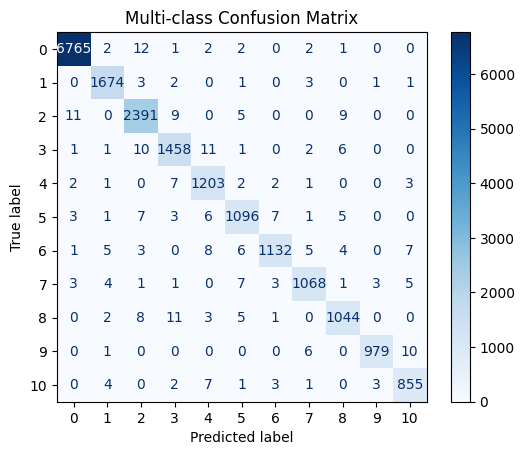

In [75]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Multi-class Confusion Matrix")
plt.show()